# 单相流计算算例
单相流1D算例, 问题模型，瞬态达西单相流
- 网格数量：$(nx, ny, nz) = (100, 1, 1)$；
- 该网格表示在一个长度方向上的 100 个单元；
- 单元长度：$\Delta x = 1$ m；
- 时间步长：$\Delta t = 0.1$ s；
- 初始压力分布：$P(x, 0) = 10^6$ Pa（均匀分布）；
- 左边界为定压边界：$P_{left}(t) = 10^6$ Pa；
- 右边界为定压边界：$P_{right}(t) = 10^5$ Pa；
- 渗透率：$k = 10^{-12}$ m²；
- 黏度：$\mu = 10^{-3}$ Pa·s；
- 孔隙度：$\phi = 0.2$；
- 源汇项：$q = 0$（无注入或生产）。
## 1. 配置参数
我们这个示例会带你从头开始一步一步了解整个计算流程，后续再使用Simulator 类创建一个对象，将这些过程全部整合。

In [1]:
import numpy as np
from reservoirpy import (
    ReservoirSimulator,
    SinglePhaseProperties,
    StructuredMesh,
    WellManager,
    validate_well_config,
)
from reservoirpy.core.discretization import FVMDiscretizer
from reservoirpy.visualization.plot_3d import create_3d_plotter

# 1. 使用字典配置
config = {
    'mesh': {
        'nx': 10, 'ny': 10, 'nz': 1,
        'dx': 10, 'dy': 10, 'dz': 10
    },
    'physics': {
        'type': 'single_phase',
        'permeability': 10.0,  # mD
        'porosity': 0.2,
        'viscosity': 0.001,     # Pa·s
        'compressibility': 1e-9  # 1/Pa
    },
    'wells': [
        {'location': [0, 0, 0],      # 井位置
        'control_type': 'bhp',      # 定井底流压控制
        'value': 100000,            # 井底流压值（Pa），通常低于地层压力
        'rw': 0.05,                 # 井筒半径
        'skin_factor': 0            # 表皮因子
        }  # 只保留一口生产井
    ],
    'simulation': {
        'dt': 720,           # 时间步长(秒)
        'total_time': 36000,  # 减少模拟时间
        'initial_pressure': 300000 # 初始压力(Pa)
    }
}


## 2. 创建网格

In [2]:
mesh_config = config['mesh']
mesh = StructuredMesh(**mesh_config)
print(mesh)

StructuredMesh(nz=1, ny=10, nx=10), shape: (1x10x10, cells=100)


## 3. 创建物理场

In [3]:
physics_config = config['physics']
physics = SinglePhaseProperties(mesh, physics_config)
print( physics)

## 4. 初始化井管理器 (WellManager)

In [5]:

# 验证井配置是否有效
for well_config in config['wells']:
    if not validate_well_config(well_config, mesh):
        print("Invalid well configuration:", well_config)
    else:
        print("Valid well configuration:", well_config)

well_manager = WellManager(mesh, config['wells'])
print(well_manager)

Valid well configuration: {'location': [0, 0, 0], 'control_type': 'bhp', 'value': 100000, 'rw': 0.05, 'skin_factor': 0}


### 4.1计算产能指数

In [ ]:
# 修改为使用属性管理器获取渗透率
permeability = physics.property_manager.properties['permeability']
if isinstance(permeability, float):
    # 如果是均匀渗透率场，创建一个合适的数组
    nx, ny, nz = mesh.grid_shape
    permeability = np.full((nz, ny, nx), permeability)

well_manager.initialize_wells(permeability, physics.viscosity)


## 5. FVM 离散化

In [7]:

discretizer = FVMDiscretizer(mesh, physics)
pressure = np.ones(mesh.n_cells) * config['simulation']['initial_pressure']
A, b = discretizer.discretize_single_phase(config['simulation']['dt'], pressure, well_manager)
print(A.shape, b.shape)

(100, 100) (100,)


## 6. 循环模拟

In [11]:
for t in range(50):  # 只运行50个时间步进行测试
    # print(f"Time step {t}")
    # 6. 模拟
    pressure_new = discretizer.solve_linear_system(A, b)

    # print("Pressure:", pressure_new)
    
    # 检查是否有nan值
    if np.any(np.isnan(pressure_new)):
        print("NaN detected! Breaking simulation.")
        break
        
    # 更新网格单元中的压力值
    for i, cell in enumerate(mesh.cell_list):
        cell.press = pressure_new[i]
        
    # 8. A, b 更新
    A, b = discretizer.discretize_single_phase(config['simulation']['dt'], pressure_new, well_manager)
    pressure = pressure_new.copy()

print(f"Simulation completed after {t+1} time steps.")
print("Final pressure:", pressure)


Simulation completed after 50 time steps.
Final pressure: [141612.82289853 177039.81482474 198168.06515213 212360.19300923
 222547.59054163 230066.52838574 235597.4299761  239514.30809943
 242029.91964232 243261.5141311  177039.81482474 190933.45915331
 204588.03816546 215774.22989823 224571.90296698 231371.01125862
 236498.95270738 240182.59721689 242567.82256793 243740.56647537
 198168.06515213 204588.03816546 212926.52332487 220968.18424499
 227940.03627677 233656.30690529 238127.59032003 241412.88078242
 243569.33082389 244637.37068885 212360.19300923 215774.22989823
 220968.18424499 226596.11563944 231891.39775694 236484.32262971
 240216.59641925 243029.23188566 244905.23757388 245842.63733612
 222547.59054163 224571.90296698 227940.03627677 231891.39775694
 235852.11680398 239456.00900088 242488.78911764 244831.11644905
 246418.88908725 247219.57002604 230066.52838574 231371.01125862
 233656.30690529 236484.32262971 239456.00900088 242266.37438773
 244703.23413485 246627.18299467

## 7. 可视化

/Users/czl/Developing/reservoirpy/.venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/Users/czl/Developing/reservoirpy/.venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


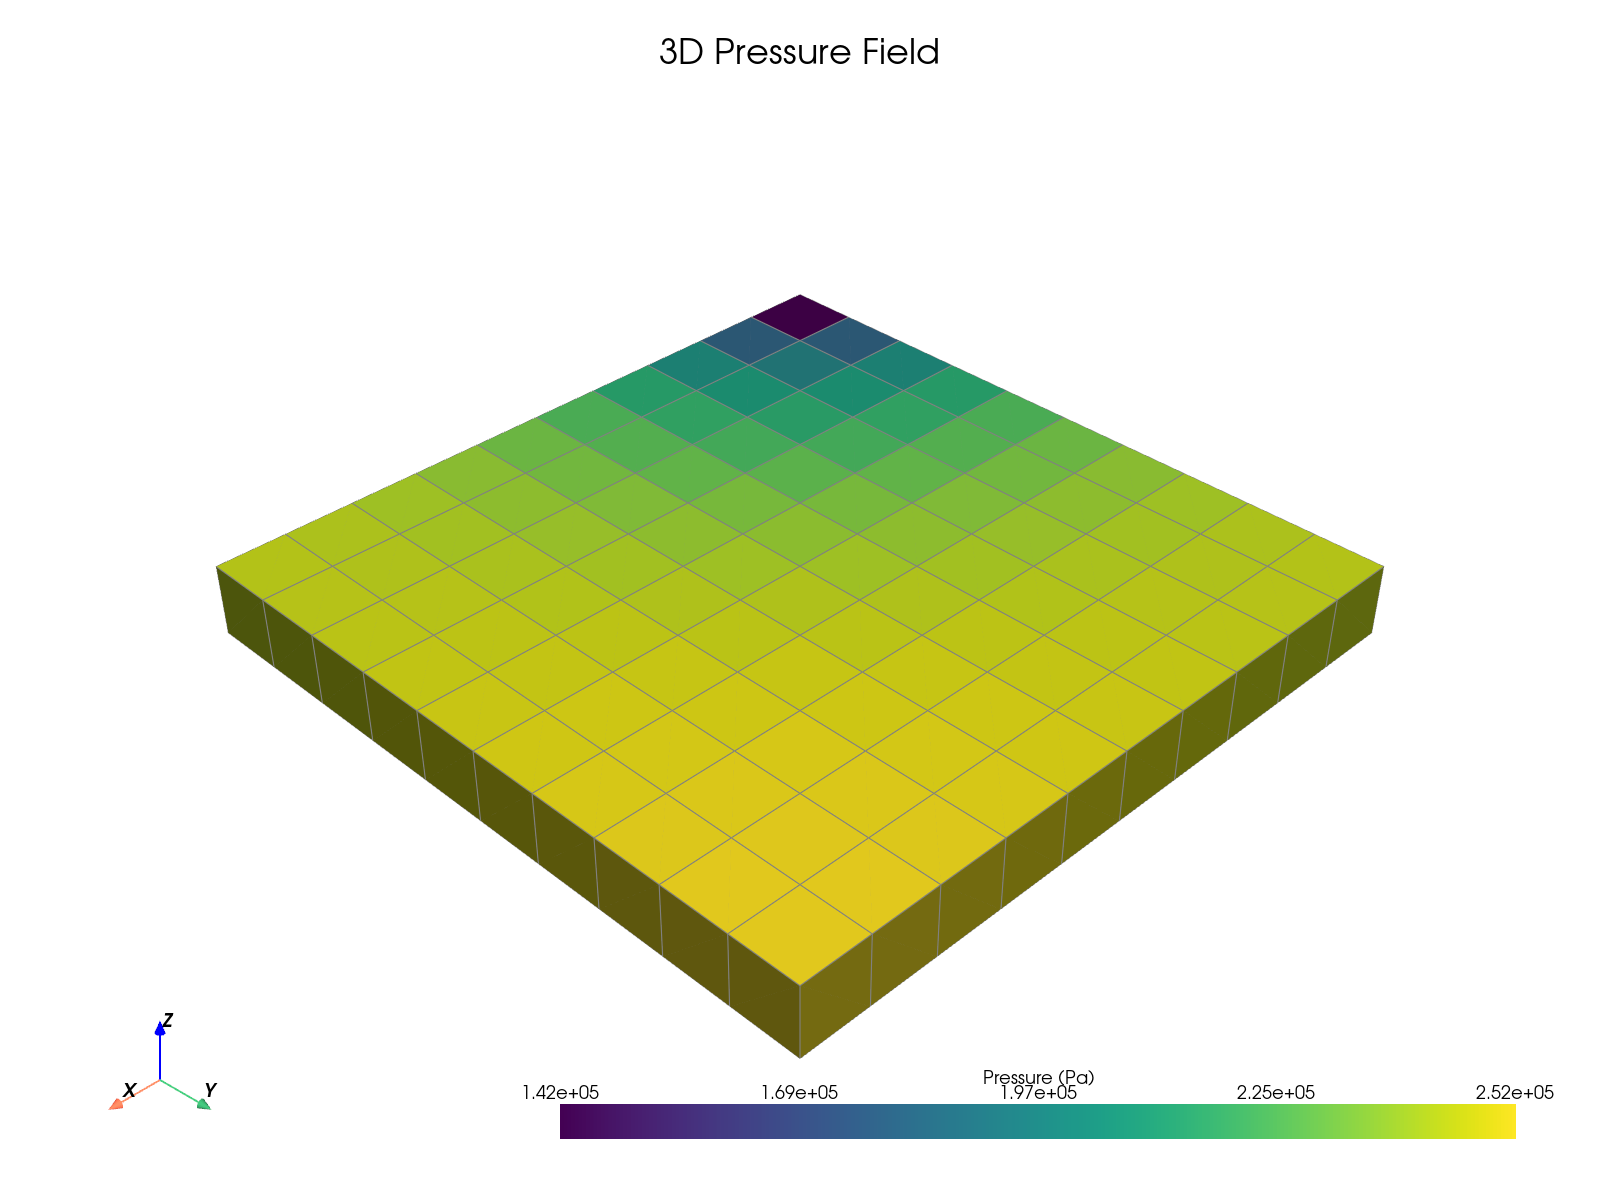

In [12]:
plotter_3d = create_3d_plotter(mesh)
pv_plotter = plotter_3d.plot_pressure_field_3d(pressure_new, "3D Pressure Field")
pv_plotter.show()

## 8. 直接使用Simulator class 进行模拟